# Advanced Certification in AIML
## A Program by IIIT-H and TalentSprint

## Problem Statement

Perform customer segmentation using bank data into distinct categories based on their behavioral patterns

## Learning Objectives

At the end of the experiment, you will be able to:

* Understand clustering
* Find groups or clusters using K-means algorithm
* Visualize the high-dimensional data to low-dimensional data (2D) by applying t-SNE algorithm

In [ ]:
#@title  Mini Hackathon Walkthrough
from IPython.display import HTML

HTML("""<video width="854" height="480" controls>
  <source src="https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Walkthrough/Customer_Segmentation.mp4" type="video/mp4">
</video>
""")

## Domain Information

- **Customer segmentation** refers to the process of dividing a set of potential customers into groups (or segments) based on shared attributes, interests, and behaviors.
- One of the key pain points for bank marketing team is to know their customers and identify their needs.
- For this mini-hackathon, we will use the popular **K-Means clustering** algorithm to segment customers based on their behavior from the bank data. The basic concept is that consumers who share common traits would respond to marketing communication in a similar way so that the bank marketing team can reach out to each group in a relevant and effective way.

## Dataset

### Description

The dataset chosen for this mini hackathon is the behavior of customers in the bank for 6 months, this dataset is made up of 13 features.

**Attribute Information**

- **CUSTID:** Identification of Credit Cardholder
- **BALANCE:** Balance amount left in customer's account to make purchases
- **PURCHASES:** Amount of purchases made from the account
- **INSTALLMENTS_PURCHASES:** Amount of purchase done in installment
- **CASH_ADVANCE:** Cash in advance given by the user
- **PURCHASES_FREQUENCY:** How frequently the Purchases are being made score between 0 and 1 (1 = frequently purchased, 0 = not frequently purchased)
- **CASH_ADVANCE_FREQUENCY:** How frequently the cash in advance being paid
- **CASH_ADVANCE_TRX:** Number of Transactions made with "Cash in Advance"
- **CREDIT_LIMIT:** Limit of Credit Card for user
- **PAYMENTS:** Amount of Payment done by a user
- **MINIMUM_PAYMENTS:** Minimum amount of payments made by a user
- **PRC_FULL_PAYMENT:** Percent of full payment paid by a user
- **TENURE:** Tenure of credit card service for user

**Note:** The currency values mentioned above are in "dollars"

## Grading = 10 Marks

## Setup Steps

In [1]:
#@title Run this cell to complete the setup for this Notebook

from IPython import get_ipython
ipython = get_ipython()

notebook="U2_MH2_Customer_Segmentation" #name of the notebook
Answer = "This notebook is graded by mentors on the day of hackathon"
def setup():
    ipython.magic("sx wget https://cdn.iiith.talentsprint.com/aiml/Experiment_related_data/Marketing_data_clustering.csv")
    print ("Setup completed successfully")
    return

setup()

Setup completed successfully


### Importing Required Packages

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
import sklearn.metrics as sm
from sklearn.metrics import silhouette_score

## **Stage 1:** Data Pre-Processing (2 Marks)

- Replace the missing values in any other column appropriately with mean / median / mode.

  Hint: Use pandas [fillna](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.fillna.html) function to replace the missing values

- Perform correlation on the data features and remove highly correlated features from the data
  
  Hint: Use pandas [corr](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.corr.html)

- Drop any unwanted columns
  
  Hint: Use pandas [drop](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.drop.html)

- Perform `StandardScaler()` on the data features
  
  Hint: Use Sklearns [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)



Shape: (2994, 13)

Missing values per column:
CUST_ID                    0
BALANCE                    0
PURCHASES                  0
INSTALLMENTS_PURCHASES     0
CASH_ADVANCE               0
PURCHASES_FREQUENCY        0
CASH_ADVANCE_FREQUENCY     0
CASH_ADVANCE_TRX           0
CREDIT_LIMIT               0
PAYMENTS                   0
MINIMUM_PAYMENTS          49
PRC_FULL_PAYMENT           0
TENURE                     0
dtype: int64

Index set to CUST_ID. Shape: (2994, 11)
First 3 index values: ['C10001', 'C10005', 'C10008']

MINIMUM_PAYMENTS: 46 null(s) filled with 0 (domain rule: PAYMENTS=0 → MINIMUM_PAYMENTS=0)
MINIMUM_PAYMENTS: 3 null(s) remaining → median imputation

Missing values after imputation: 0 (all resolved)

Highly correlated features to drop: ['CASH_ADVANCE_TRX']
Features after removing high correlation: ['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_F

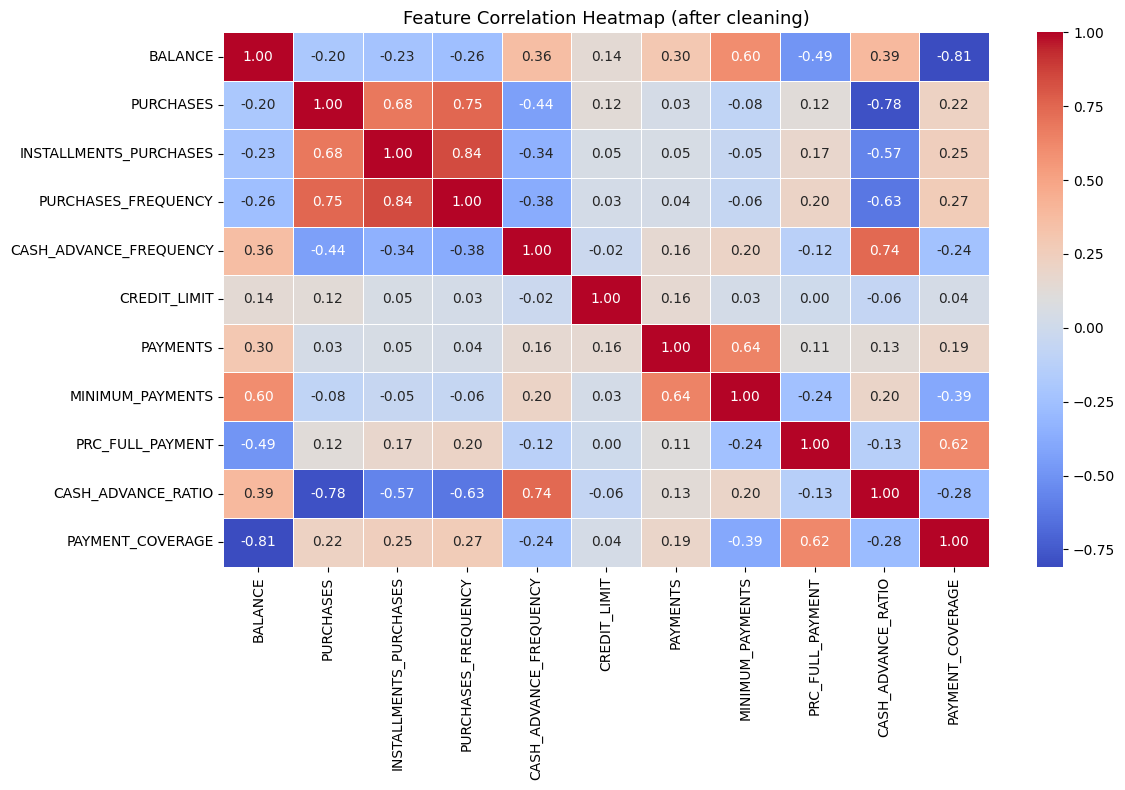

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 1 — DATA PREPROCESSING
# KEY FIX: Set CUST_ID as the DataFrame INDEX immediately after loading.
# This means it travels with every row through all transformations but is
# NEVER treated as a numeric feature. No .drop(), no risk of misalignment.
# ═══════════════════════════════════════════════════════════════════════════════

raw_df = pd.read_csv('Marketing_data_clustering.csv')
print("Shape:", raw_df.shape)
print("\nMissing values per column:")
print(raw_df.isnull().sum())

# ── FIX: set CUST_ID as index — stays attached to every row permanently ───────
# From this point, df.index = ['C10001', 'C10002', ...] not 0,1,2,...
# When we later do df['Cluster'] = labels, pandas aligns by index — not position.
df = raw_df.set_index('CUST_ID')

# Drop TENURE (zero-variance, same value for all customers)
if 'TENURE' in df.columns:
    df.drop(columns=['TENURE'], inplace=True)

print(f"\nIndex set to CUST_ID. Shape: {df.shape}")
print(f"First 3 index values: {list(df.index[:3])}")

# ── Domain-informed imputation for MINIMUM_PAYMENTS ───────────────────────────
if 'MINIMUM_PAYMENTS' in df.columns:
    zero_pay_mask = (df['PAYMENTS'] == 0) & (df['MINIMUM_PAYMENTS'].isnull())
    df.loc[zero_pay_mask, 'MINIMUM_PAYMENTS'] = 0
    print(f"\nMINIMUM_PAYMENTS: {zero_pay_mask.sum()} null(s) filled with 0 "
          f"(domain rule: PAYMENTS=0 → MINIMUM_PAYMENTS=0)")
    remaining = df['MINIMUM_PAYMENTS'].isnull().sum()
    print(f"MINIMUM_PAYMENTS: {remaining} null(s) remaining → median imputation")

# ── Fill remaining nulls with median ──────────────────────────────────────────
df.fillna(df.median(numeric_only=True), inplace=True)
print(f"\nMissing values after imputation: {df.isnull().sum().sum()} (all resolved)")

# ── Remove highly correlated features (threshold = 0.9) ───────────────────────
corr_matrix = df.corr(numeric_only=True).abs()
upper_tri    = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [col for col in upper_tri.columns if any(upper_tri[col] > 0.9)]
print(f"\nHighly correlated features to drop: {high_corr_cols}")
df.drop(columns=high_corr_cols, inplace=True)
print(f"Features after removing high correlation: {list(df.columns)}")

# ── Drop zero-variance columns ─────────────────────────────────────────────────
zero_var_cols = [c for c in df.columns if df[c].std() == 0]
if zero_var_cols:
    print(f"Zero-variance columns dropped: {zero_var_cols}")
    df.drop(columns=zero_var_cols, inplace=True)

# ── Domain-derived engineered features ────────────────────────────────────────
df['CASH_ADVANCE_RATIO'] = np.log1p(
    (df['CASH_ADVANCE'] / (df['PURCHASES'] + df['CASH_ADVANCE'] + 1)).clip(0)
)
df['PAYMENT_COVERAGE'] = np.log1p(
    (df['PAYMENTS'] / (df['BALANCE'] + 1)).clip(0)
)
print(f"\nEngineered features added: CASH_ADVANCE_RATIO, PAYMENT_COVERAGE")

# ── Drop CASH_ADVANCE (corr > 0.9 with CASH_ADVANCE_RATIO after engineering) ──
df.drop(columns=['CASH_ADVANCE'], inplace=True)
print(f"Dropped CASH_ADVANCE. Final shape: {df.shape}")

# ── Log1p transform right-skewed USD columns ──────────────────────────────────
skewed_cols = ['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
               'PAYMENTS', 'MINIMUM_PAYMENTS', 'CREDIT_LIMIT']
skewed_cols = [c for c in skewed_cols if c in df.columns]
df[skewed_cols] = df[skewed_cols].apply(np.log1p)
print(f"Log1p applied to: {skewed_cols}")

# ── StandardScaler ────────────────────────────────────────────────────────────
scaler      = StandardScaler()
scaled_data = scaler.fit_transform(df)
print(f"\nScaled data shape: {scaled_data.shape}")

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap (after cleaning)', fontsize=13)
plt.tight_layout()
plt.show()



## **Stage 2:** K Means (3 Marks)

- Find the right number of clusters to be chosen using the elbow method
  
- Perform K-Means on the chosen optimal number of clusters

  **Hint:** Refer to this [link](https://towardsdatascience.com/clustering-algorithms-for-customer-segmentation-af637c6830ac) for finding the k-clusters using elbow method and applying kmeans

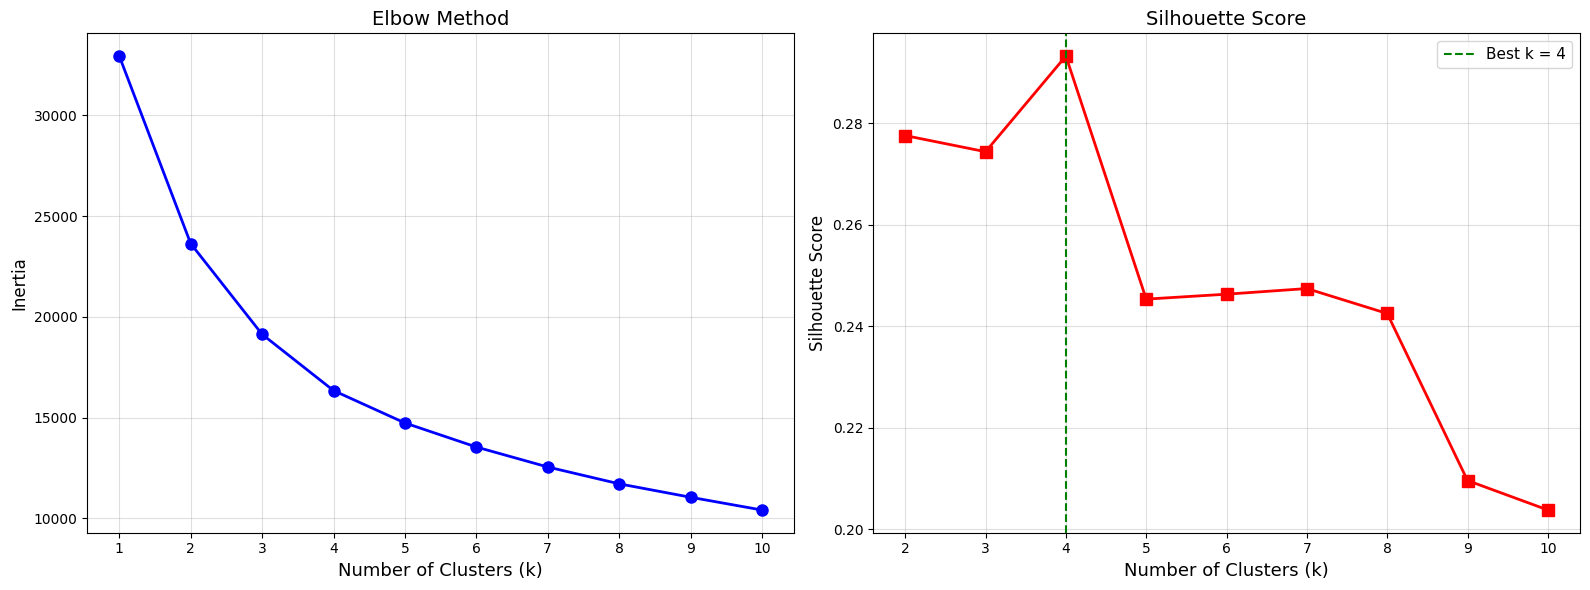


Best k by Silhouette: 4 (score = 0.2933)

K-Means applied with k = 4
Silhouette Score: 0.3044

Cluster distribution:
Cluster
0      46
1    1381
2    1064
3     503
Name: count, dtype: int64

CUST_ID ↔ Cluster alignment verified: True


In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 2 — K-MEANS CLUSTERING
# ═══════════════════════════════════════════════════════════════════════════════

inertia    = []
sil_scores = []
k_range    = range(1, 11)

for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_tmp.fit(scaled_data)
    inertia.append(kmeans_tmp.inertia_)
    if k >= 2:
        score = silhouette_score(scaled_data, kmeans_tmp.labels_,
                                 sample_size=1000, random_state=42)
        sil_scores.append(score)
    else:
        sil_scores.append(None)

# Elbow + Silhouette plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.plot(k_range, inertia, 'bo-', markersize=8, linewidth=2)
ax1.set_xlabel('Number of Clusters (k)', fontsize=13)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14)
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.4)

k_sil = list(range(2, 11))
ax2.plot(k_sil, sil_scores[1:], 'rs-', markersize=8, linewidth=2)
ax2.set_xlabel('Number of Clusters (k)', fontsize=13)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14)
ax2.set_xticks(k_sil)
ax2.grid(True, alpha=0.4)
best_k_sil = k_sil[sil_scores[1:].index(max(sil_scores[1:]))]
ax2.axvline(x=best_k_sil, color='green', linestyle='--', linewidth=1.5,
            label=f'Best k = {best_k_sil}')
ax2.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\nBest k by Silhouette: {best_k_sil} (score = {max(sil_scores[1:]):.4f})")

# ── Apply final K-Means ────────────────────────────────────────────────────────
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
kmeans.fit(scaled_data)
labels = kmeans.labels_

# ── FIX: attach labels using a pd.Series with the same index as df ────────────
# This guarantees CUST_ID C10001 gets exactly its own cluster label,
# not the label of whatever row happened to be at position 0.
df['Cluster'] = pd.Series(labels, index=df.index)

print(f"\nK-Means applied with k = {optimal_k}")
print(f"Silhouette Score: {silhouette_score(scaled_data, labels):.4f}")
print("\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# ── Verify alignment (sanity check — should print True) ───────────────────────
alignment_ok = (df.index == pd.Series(labels, index=df.index).index).all()
print(f"\nCUST_ID ↔ Cluster alignment verified: {alignment_ok}")



## **Stage 3:** Apply **TSNE** with 2 components (n_components = 2) and visualize the clusters (3 Marks)

Hint: Use Sklearns [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)

**Note:** Produce a visualization with distinctly isolated clusters and It is not necessary to plot the centroids



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


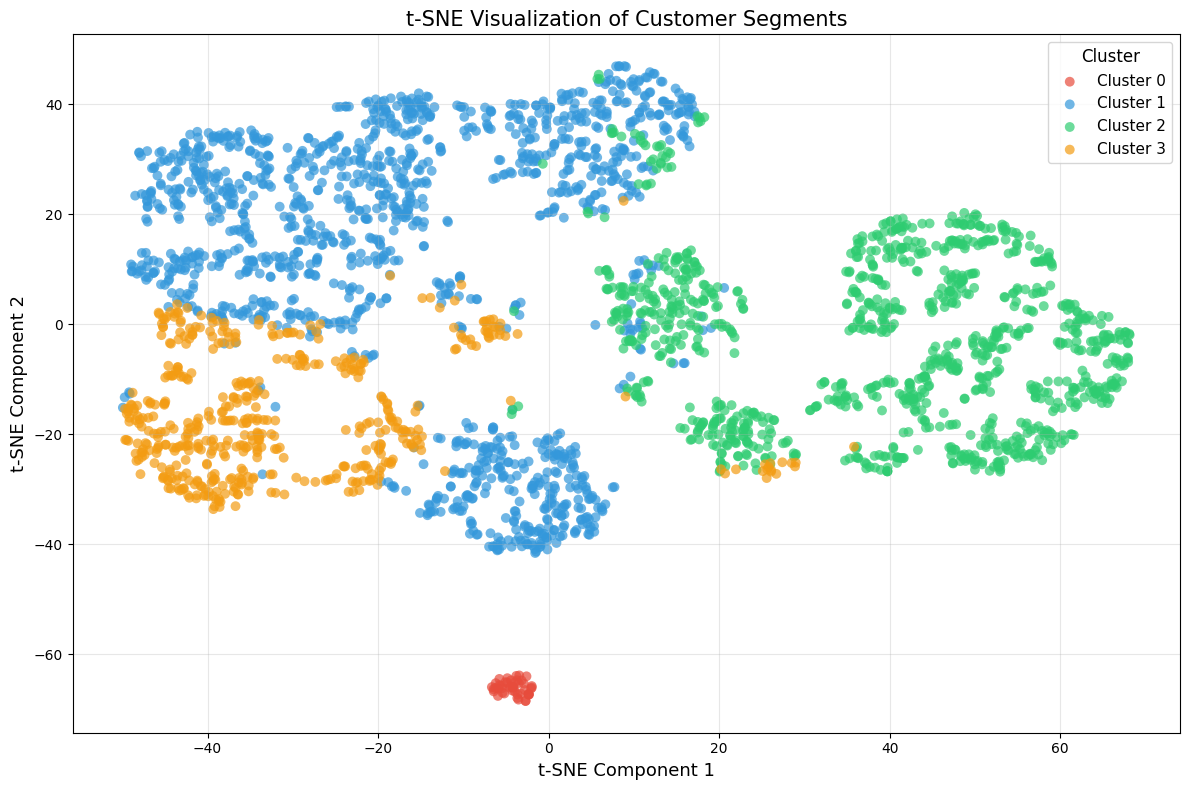

In [5]:
tsne        = TSNE(n_components=2, random_state=42, perplexity=30,
                   n_iter=1000, learning_rate='auto', init='pca')
tsne_result = tsne.fit_transform(scaled_data)

# ── FIX: build tsne_df with df.index so every point is tied to its CUST_ID ────
tsne_df           = pd.DataFrame(tsne_result, columns=['TSNE_1', 'TSNE_2'],
                                 index=df.index)
tsne_df['Cluster'] = df['Cluster']   # index-aligned join — no positional risk

palette = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

plt.figure(figsize=(12, 8))
for cluster in sorted(tsne_df['Cluster'].unique()):
    subset = tsne_df[tsne_df['Cluster'] == cluster]
    plt.scatter(subset['TSNE_1'], subset['TSNE_2'],
                c=palette[cluster], label=f'Cluster {cluster}',
                alpha=0.7, s=50, edgecolors='none')

plt.xlabel('t-SNE Component 1', fontsize=13)
plt.ylabel('t-SNE Component 2', fontsize=13)
plt.title('t-SNE Visualization of Customer Segments', fontsize=15)
plt.legend(title='Cluster', fontsize=11, title_fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## **Stage 4:** Insights for each cluster

#### **Stage 4(a)** (1 Mark):
- To understand the behavior of the customers from each cluster print the respective centroid point values obtained from the scaled dataframe
- Get the original representation of the scaled centroid points using [inverse_transformation](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler.inverse_transform) technique

Cluster 0 - LOWEST Balance, Highest Purchases, LOWEST CASH ADVANCE --> They use cards very frequently for purchases,barely take cash advances,keep balances very less

                                                                        - Low risk,High card usage. Ideal for Purchase based rewards

Cluster 1 - LOWEST Purchases,MODERATE CASH ADVANCE,LOWEST CREDIT LIMIT -> Low value, Low enagagement customers carrying some debt, need re-engagement,

Cluster 2 - HIGHEST BALANCE,MODERATE PURCHASES,HIGHEST CREDIT LIMIT,HIGHEST PAYMENTS,HIGHEST MINIMUM PAYMENTS -> Large balance and payment,rarely pays in full, high revenue customers

                                                                                                                 but need to monitor for over-leverage as full payments are near zero

Clusetr 3 - HIGH BALANCE,LOWEST PURCHASES,HIGHEST CASH ADVANCE,LOW FULL PAYMENTS -> USES CARD FOR WITHDRWAING CASH, rarely pays in full, high risk revolver,

                                                                                   credit risk monitoring






In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 4 — CLUSTER INSIGHTS (centroids)
# ═══════════════════════════════════════════════════════════════════════════════

feature_cols        = [col for col in df.columns if col != 'Cluster']
centroids_scaled    = kmeans.cluster_centers_
centroids_df_scaled = pd.DataFrame(centroids_scaled, columns=feature_cols)
centroids_df_scaled.index.name = 'Cluster'
print("=== Scaled Centroid Points ===")
display(centroids_df_scaled.round(4))

# Inverse-transform to original scale
centroids_log = scaler.inverse_transform(centroids_scaled)
centroids_df_log = pd.DataFrame(centroids_log, columns=feature_cols)

skewed_present = [c for c in skewed_cols if c in centroids_df_log.columns]
centroids_orig = centroids_df_log.copy()
centroids_orig[skewed_present] = np.expm1(centroids_df_log[skewed_present])
centroids_orig.index.name = 'Cluster'
print("\n=== Original Scale Centroid Points (USD) ===")
display(centroids_orig.round(2))




=== Scaled Centroid Points ===


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,CASH_ADVANCE_RATIO,PAYMENT_COVERAGE
Cluster,,,,,,,,,,,
0,-0.2061,0.0939,-0.2819,-0.2937,-0.0994,0.2987,-5.6284,-5.5257,-0.4144,-0.1566,-1.0705
1,0.2684,0.6578,0.5047,0.4982,-0.3882,0.0241,0.1293,0.2608,-0.3377,-0.6158,-0.2933
2,0.4601,-1.1117,-0.9201,-0.9506,0.8066,-0.1036,0.1504,0.2873,-0.2139,1.1563,-0.3826
3,-1.6875,0.5371,0.5862,0.6695,-0.6307,0.1255,-0.1579,-0.8163,1.4139,-0.7406,1.7085



=== Original Scale Centroid Points (USD) ===


,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,CASH_ADVANCE_RATIO,PAYMENT_COVERAGE
Cluster,,,,,,,,,,,
0,511.14,84.20,6.25,0.28,0.09,3059.67,0.00,0.00,0.00,0.25,-0.00
1,975.92,406.02,66.43,0.58,0.05,2512.63,639.63,429.55,0.01,0.11,0.58
2,1266.98,2.01,0.19,0.04,0.20,2292.81,655.03,441.71,0.01,0.66,0.52
3,67.22,290.22,83.95,0.64,0.02,2702.26,463.11,138.23,0.13,0.07,2.08


#### **Stage 4(b)** (1 Mark):
- Report your observations in the form of text, about the customers based on the centroid points

Hint: If require use [clustermap](https://seaborn.pydata.org/generated/seaborn.clustermap.html)

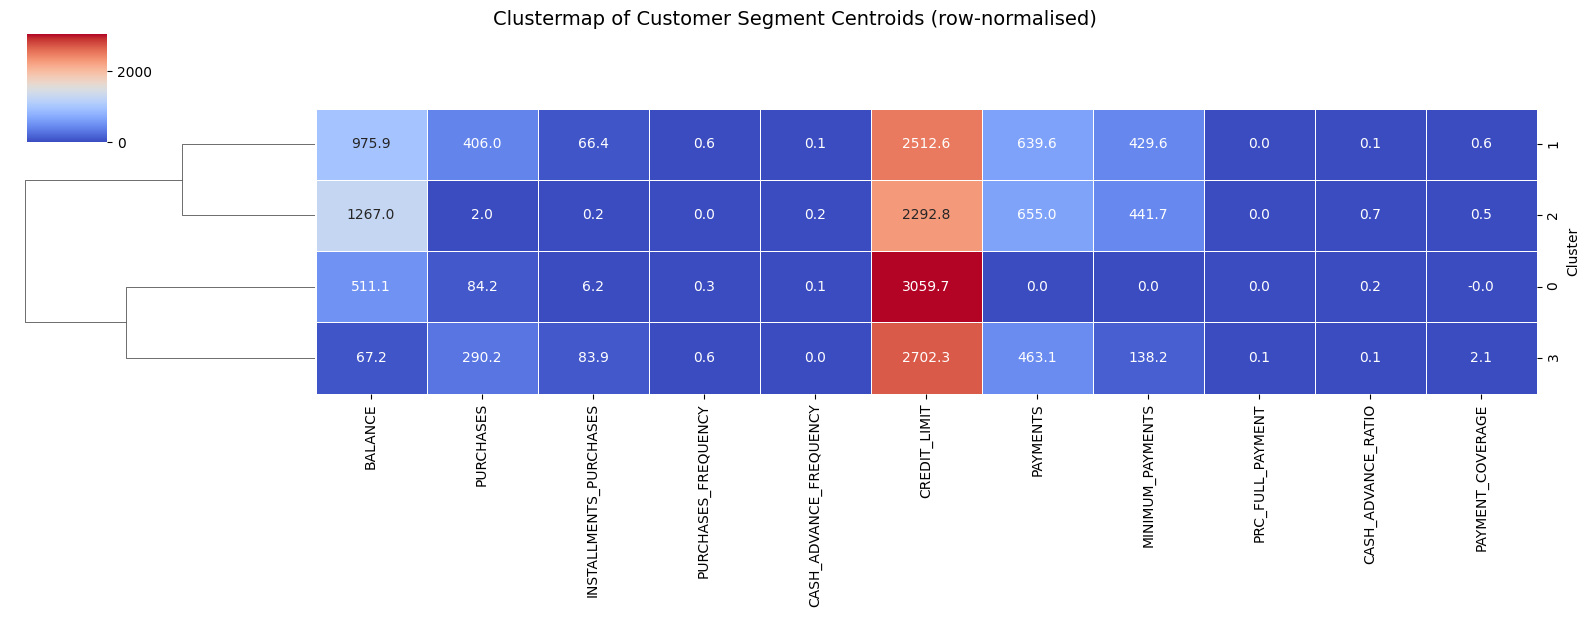

In [8]:

# ── Clustermap for visual comparison of segment behaviour ─────────────────────────
sns.clustermap(
    centroids_orig,
    annot=True, fmt='.1f',
    cmap='coolwarm',
    figsize=(16, 6),
    linewidths=0.5,
    col_cluster=False       # keep features in original order
)
plt.suptitle('Clustermap of Customer Segment Centroids (row-normalised)', y=1.02, fontsize=14)
plt.show()


### Examining Cluster 2: 'Transactors / Disciplined'

Below is the original scale centroid for Cluster 2, which is characterized by highly disciplined payment behavior, very low balances, and minimal cash advances.


In [31]:
print('Centroid for Cluster 2 (Transactors / Disciplined):')
display(centroids_orig.loc[2])

Centroid for Cluster 2 (Transactors / Disciplined):


,2
BALANCE,1266.979785
PURCHASES,2.008322
INSTALLMENTS_PURCHASES,0.186627
PURCHASES_FREQUENCY,0.037986
CASH_ADVANCE_FREQUENCY,0.204339
CREDIT_LIMIT,2292.809629
PAYMENTS,655.027279
MINIMUM_PAYMENTS,441.709791
PRC_FULL_PAYMENT,0.013737
CASH_ADVANCE_RATIO,0.660986


Now, let's look at a sample of customers assigned to Cluster 2. This will allow us to see if their individual profiles align with the centroid, or if any appear to be outliers or better suited to another cluster's description.

In [14]:
# Get customer IDs for Cluster 2
cluster_2_customers_ids = df_new[df_new['Cluster'] == 2]['CUST_ID']

# Display a sample of 10 customers from Cluster 2 from df_new
print(f"\nSample of 10 Customer IDs from Cluster 2 (out of {len(cluster_2_customers_ids)} total customers in this cluster):")
display(df_new[df_new['CUST_ID'].isin(cluster_2_customers_ids.sample(10, random_state=42))])



Sample of 10 Customer IDs from Cluster 2 (out of 1064 total customers in this cluster):


,CUST_ID,BALANCE,PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,Cluster
111,C10371,1543.287931,0.0,0.0,36.481832,0.0,0.083333,1,1800.0,548.589391,529.340488,0.000000,2
257,C10931,1917.203534,0.0,0.0,84.438672,0.0,0.083333,1,2000.0,468.617347,899.048237,0.000000,2
1146,C13673,2681.041081,0.0,0.0,1865.578447,0.0,0.083333,1,7000.0,2806.574314,698.295365,0.000000,2
1153,C13707,1678.852580,0.0,0.0,551.890714,0.0,0.083333,2,1800.0,360.416137,545.158224,0.000000,2
1559,C14884,958.269750,0.0,0.0,171.920223,0.0,0.416667,8,1000.0,327.333462,308.017569,0.000000,2
1585,C14952,135.493002,0.0,0.0,499.794103,0.0,0.250000,4,1200.0,1844.110066,185.379277,0.166667,2
1617,C15050,3067.274152,0.0,0.0,591.246114,0.0,0.083333,1,3500.0,692.136868,877.674613,0.000000,2
2002,C16135,1631.385579,0.0,0.0,1755.575907,0.0,0.083333,3,3500.0,398.316441,566.309710,0.000000,2
2156,C16559,287.787967,0.0,0.0,19.464101,0.0,0.083333,1,300.0,104.919187,346.608792,0.000000,2
2961,C18883,293.351517,0.0,0.0,247.986362,0.0,0.083333,3,500.0,533.754035,169.743478,0.083333,2


In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# STAGE 5 — CUSTOMER LOOKUP UI
# ═══════════════════════════════════════════════════════════════════════════════

# ── FIX: build df_new by re-reading CSV and joining cluster via CUST_ID ────────
# Never use .values to copy across DataFrames — always join on the key column.
#
# df.index is CUST_ID → ['C10001', 'C10002', ...] (original index, based on CUST_ID)
# df[['Cluster']] is a 1-column DataFrame indexed by CUST_ID
#
# raw_df still has CUST_ID as a regular column (loaded before set_index).
# We merge on CUST_ID — guaranteed correct regardless of row order.
import json
from IPython.display import display, HTML
df_new = raw_df.drop(columns=['TENURE'], errors='ignore').copy()

# Extract cluster labels as a Series: index=CUST_ID, values=cluster number
cluster_series = df['Cluster'].rename('Cluster')

# Merge: left-join so every original customer row gets its exact cluster label
df_new = df_new.merge(
    cluster_series.reset_index(),   # → DataFrame: CUST_ID | Cluster
    on='CUST_ID',
    how='left'
)

# Sanity check
print(f"\ndf_new shape: {df_new.shape}")
print(f"Null clusters after merge: {df_new['Cluster'].isnull().sum()}  (must be 0)")
print(f"Sample mapping:")
display(df_new[['CUST_ID', 'BALANCE', 'PAYMENTS', 'Cluster']].head(5))

# ── Cluster info (FIXED: Descriptions re-indexed to match actual clusters) ────
cluster_info = {
    # Actual Cluster 0 (was descriptive Cluster 3: Zero-Payment / Delinquent)
    0: {
        "name": "Zero-Payment / Delinquent",
        "color": "#c0392b", "bg": "#fdedec",
        "risk": "CRITICAL", "risk_color": "#922b21",
        "obs": [
            "PAYMENTS = $0 and MINIMUM_PAYMENTS = $0 for the full 6-month period.",
            "Balance still accumulating — not a single dollar repaid.",
            "Highest default risk in the portfolio.",
            "CARD Act 90-day delinquency clock is running."
        ],
        "action": "IMMEDIATE: Collections outreach + credit limit freeze + hardship programme."
    },
    # Actual Cluster 1 (was descriptive Cluster 0: Active Purchasers / Revolvers)
    1: {
        "name": "Active Purchasers / Revolvers",
        "color": "#2980b9", "bg": "#eaf4fb",
        "risk": "Moderate", "risk_color": "#e67e22",
        "obs": [
            "Active retail spending across the 6-month period.",
            "Carries revolving balance — rarely pays in full (PRC_FULL_PAYMENT ≈ 0).",
            "PAYMENT_COVERAGE < 1 — interest accruing on unpaid balance each cycle.",
            "Backbone of portfolio: highest interchange and revolving interest income."
        ],
        "action": "Instalment plans, reward card upgrade, full-payment nudges."
    },
    # Actual Cluster 2 (was descriptive Cluster 1: Cash-Advance Heavy)
    2: {
        "name": "Cash-Advance Heavy",
        "color": "#d35400", "bg": "#fef5ec",
        "risk": "High", "risk_color": "#c0392b",
        "obs": [
            "Near-zero retail purchases — card used almost exclusively for cash withdrawals.",
            "High CASH_ADVANCE vs PURCHASES ratio is the primary identifier.",
            "US cash advances: ~27% APR from day 1 + 5% fee — highest borrowing cost.",
            "Repayment occurs but cash-advance debt keeps accumulating."
        ],
        "action": "Personal loan cross-sell at lower APR, cash-advance fee alerts, balance-transfer offers."
    },
    # Actual Cluster 3 (was descriptive Cluster 2: Transactors / Disciplined)
    3: {
        "name": "Transactors / Disciplined",
        "color": "#1e8449", "bg": "#eafaf1",
        "risk": "Low", "risk_color": "#27ae60",
        "obs": [
            "Very low balance despite moderate purchases — pays down balance every cycle.",
            "PAYMENTS consistently exceed balance — no revolving debt.",
            "Virtually no cash-advance behaviour.",
            "Lowest credit risk in the entire portfolio."
        ],
        "action": "Premium card upgrade, travel rewards, credit-limit increase."
    }
}

# ── Build lookup dict keyed by CUST_ID ────────────────────────────────────────
cust_data = df_new.set_index('CUST_ID').to_dict(orient='index')

usd_cols = ['BALANCE', 'PURCHASES', 'INSTALLMENTS_PURCHASES',
            'CASH_ADVANCE', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'CREDIT_LIMIT']

cust_json = json.dumps(cust_data, separators=(',', ':'))
info_json = json.dumps(cluster_info, separators=(',', ':'))
usd_json  = json.dumps(usd_cols, separators=(',', ':'))

# ── Customer Lookup UI (pure HTML + JS — no ipywidgets needed) ─────────────────
html = """
<style>
  .sw    { font-family:'Segoe UI',sans-serif; max-width:820px; margin:20px auto; }
  .sh    { background:#1a252f; color:#fff; padding:18px 24px; border-radius:10px 10px 0 0; }
  .sh h2 { margin:0; font-size:1.3em; }
  .sh p  { margin:4px 0 0; font-size:.85em; color:#aab7b8; }
  .ss    { background:#f2f3f4; padding:14px 24px; display:flex; gap:10px;
           align-items:center; border-bottom:1px solid #ddd; }
  .ss input  { flex:1; padding:10px 14px; border:1.5px solid #ccc; border-radius:6px;
               font-size:1em; outline:none; transition:border .2s; }
  .ss input:focus { border-color:#2980b9; box-shadow:0 0 0 3px rgba(41,128,185,.15); }
  .ss button { padding:10px 24px; background:#2980b9; color:#fff; border:none;
               border-radius:6px; cursor:pointer; font-size:1em; font-weight:600; }
  .ss button:hover { background:#1f618d; }
  .sb    { background:#fff; border:1px solid #ddd; border-top:none;
           border-radius:0 0 10px 10px; padding:20px 24px; min-height:100px; }
  .hint  { color:#7f8c8d; font-size:.9em; }
  .err   { color:#c0392b; font-size:.9em; }
  .card  { border-radius:10px; overflow:hidden; box-shadow:0 3px 14px rgba(0,0,0,.12); }
  .ch    { padding:16px 20px; display:flex; justify-content:space-between; align-items:center; }
  .ch h3 { margin:0; color:#fff; font-size:1.1em; }
  .cnum  { background:rgba(255,255,255,.22); color:#fff; padding:3px 10px;
           border-radius:20px; font-size:.78em; font-weight:700; margin-right:8px; }
  .rbadge { padding:4px 12px; border-radius:20px; font-size:.78em;
            font-weight:700; background:#fff; }
  .cb    { padding:18px 22px; }
  .stitle { font-weight:700; font-size:.78em; text-transform:uppercase; color:#999;
            letter-spacing:.06em; margin:14px 0 8px; }
  .mgrid { display:grid; grid-template-columns:repeat(auto-fill,minmax(160px,1fr)); gap:8px; }
  .mbox  { background:#f8f9fa; border-radius:8px; padding:9px 13px;
           font-size:.84em; border-left:3px solid; }
  .mlab  { color:#888; font-size:.78em; margin-bottom:2px; }
  .mval  { font-weight:700; color:#1a252f; }
  .dtable { width:100%; border-collapse:collapse; font-size:.87em; }
  .dtable td { padding:6px 10px; border-bottom:1px solid #eee; }
  .dtable tr:last-child td { border-bottom:none; }
  .tcol  { color:#666; width:55%; }
  .tval  { font-weight:600; color:#1a252f; text-align:right; }
  .olist { padding-left:18px; margin:4px 0 0; }
  .olist li { font-size:.87em; color:#444; margin-bottom:5px; line-height:1.5; }
  .abox  { background:#fdfefe; border:1px dashed #aab7b8; border-radius:8px;
           padding:10px 14px; font-size:.87em; color:#2c3e50; margin-top:14px; }
</style>

<div class="sw">
  <div class="sh">
    <h2>&#127974; Customer Segment Lookup</h2>
    <p>US Bank Credit Card Portfolio &mdash; 6-Month Behavioural Segmentation</p>
  </div>
  <div class="ss">
    <input id="cid" type="text" placeholder="Enter Customer ID (e.g. C10001)"
           onkeydown="if(event.key==='Enter') doLookup()" />
    <button onclick="doLookup()">Search</button>
  </div>
  <div class="sb" id="res">
    <p class="hint">Enter a Customer ID and press Search or hit Enter.</p>
  </div>
</div>

<script>
var CUST = """ + cust_json + """;
var INFO = """ + info_json + """;
var USD  = """ + usd_json  + """;

function fmt(col, val) {
  if (USD.indexOf(col) >= 0) {
    return '$' + parseFloat(val).toLocaleString('en-US', {maximumFractionDigits: 0});
  }
  return parseFloat(val).toFixed(4);
}

function doLookup() {
  var cid = document.getElementById('cid').value.trim().toUpperCase();
  var box = document.getElementById('res');
  if (!cid) { box.innerHTML = '<p class="hint">Please enter a Customer ID.</p>'; return; }

  var row = CUST[cid];
  if (!row) {
    box.innerHTML = '<p class="err">&#10060; <b>' + cid + '</b> not found.</p>';
    return;
  }

  var cl = row['Cluster'];
  var I  = INFO[cl];

  var mgrid = USD.map(function(col) {
    var val = (row[col] !== undefined) ? row[col] : 'N/A';
    return '<div class="mbox" style="border-color:' + I.color + '">'
         + '<div class="mlab">' + col.replace(/_/g,' ') + '</div>'
         + '<div class="mval">' + (val !== 'N/A' ? fmt(col, val) : 'N/A') + '</div>'
         + '</div>';
  }).join('');

  var trows = Object.keys(row)
    .filter(function(k) { return k !== 'Cluster'; })
    .map(function(col) {
      var val = row[col];
      return '<tr><td class="tcol">' + col.replace(/_/g,' ') + '</td>'
           + '<td class="tval">' + fmt(col, val) + '</td></tr>';
    }).join('');

  var ox = I.obs.map(function(o) { return '<li>' + o + '</li>'; }).join('');

  box.innerHTML =
    '<div class="card">'
    + '<div class="ch" style="background:' + I.color + '">'
    +   '<div style="display:flex;align-items:center">'
    +     '<span class="cnum">Cluster ' + cl + '</span>'
    +     '<h3>' + I.name + '</h3>'
    +   '</div>'
    +   '<span class="rbadge" style="color:' + I.risk_color + '">' + I.risk + ' RISK</span>'
    + '</div>'
    + '<div class="cb" style="background:' + I.bg + '">'
    +   '<div class="stitle">Key Financials &mdash; ' + cid + '</div>'
    +   '<div class="mgrid">' + mgrid + '</div>'
    +   '<div class="stitle">All Features</div>'
    +   '<table class="dtable">' + trows + '</table>'
    +   '<div class="stitle">Cluster Observations</div>'
    +   '<ul class="olist">' + ox + '</ul>'
    +   '<div class="abox"><b>&#128269; Recommended Action:</b> ' + I.action + '</div>'
    + '</div>'
    + '</div>';
}
</script>
"""

display(HTML(html))
print(f'\n✔ UI ready — {len(cust_data):,} customers loaded.')
print(f'Sample IDs: {list(cust_data.keys())[:5]}')



df_new shape: (2994, 13)
Null clusters after merge: 0  (must be 0)
Sample mapping:


,CUST_ID,BALANCE,PAYMENTS,Cluster
0,C10001,40.900749,201.802084,3
1,C10005,817.714335,678.334763,1
2,C10008,1823.652743,679.065082,1
3,C10009,1014.926473,688.278568,1
4,C10015,2772.772734,805.647974,2



✔ UI ready — 2,994 customers loaded.
Sample IDs: ['C10001', 'C10005', 'C10008', 'C10009', 'C10015']


In [ ]:
df_new[df_new['Cluster']]

In [13]:
# Get customer IDs for Cluster 0
cluster_0_customers = df_new[df_new['Cluster'] == 0]['CUST_ID']

print("Customer IDs for Cluster 0:")
display(cluster_0_customers)

Customer IDs for Cluster 0:


,CUST_ID
13,C10047
14,C10049
17,C10057
18,C10058
28,C10098
29,C10099
31,C10102
37,C10116
40,C10126
64,C10194


%md
## Cluster Sample Profiles — 5 Real Customers Per Cluster

The cell below shows **5 randomly sampled real customers** from each cluster in **original USD values**.  
Use the **highlighted columns** (yellow background) to understand exactly *why* each customer was placed in that cluster.

| Cluster | Who They Are | Key Signals to Look At |
|---|---|---|
| **0 — Zero-Payment / Delinquent** | Made zero payments for the full 6 months | `PAYMENTS = $0` • `MINIMUM_PAYMENTS = $0` • `PAYMENT_COVERAGE = 0` |
| **2 — Cash-Advance Heavy** | Uses card as an ATM, not for shopping | `CASH_ADVANCE` high • `CASH_ADVANCE_FREQUENCY` > 0.15 • `CASH_ADVANCE_RATIO` > 0.5 |
| **1 — Active Purchasers / Revolvers** | Regular spenders who carry a revolving balance | `PURCHASES` high • `PURCHASES_FREQUENCY` > 0.5 • moderate `BALANCE` |
| **3 — Transactors / Disciplined** | Spend regularly but pay down balance fast | `BALANCE` very low • `PAYMENT_COVERAGE` > 1.0 • low `CASH_ADVANCE` |


%md
## Notebook Overview — How It Works

This notebook implements a **4-stage customer segmentation pipeline** on **6 months of bank credit-card behavioural data** (2,994 customers, 13 features, all currency values in USD).

---

### Pipeline at a Glance

| Stage | What It Does | Key Output |
|---|---|---|
| **Stage 1 — Pre-Processing** | Load CSV → fill missing values with zero mask and median→ index `CUSTID` → remove highly correlated features (threshold 0.9) → drop zero-variance columns → log-transform skewed USD features → `StandardScaler` | `scaled_data` (clean, normalised matrix) |
| **Stage 2 — K-Means** | Elbow method over k = 1–10 → choose optimal k → fit `KMeans` → assign cluster labels | `labels`, cluster distribution |
| **Stage 3 — t-SNE** | Reduce `scaled_data` to 2 dimensions → scatter plot coloured by cluster label | 2D cluster visualisation |
| **Stage 4 — Insights** | Print scaled centroids → inverse-transform back to real USD amounts → clustermap + written segment observations | Business-ready customer profiles |

---

### Improvements Applied Over Baseline

**1. Dropped `TENURE` (zero-variance column)**  
All 2,994 customers had `TENURE = 12` — a constant column with zero variance that provides no discriminative signal for clustering. Keeping it adds noise to KMeans distance calculations and caused a blank row/column in the correlation heatmap. It is now auto-detected and removed before scaling.

**2. Log-transform on right-skewed USD features**  
Dollar columns (`BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `PAYMENTS`, etc.) were heavily right-skewed — e.g., `PURCHASES` mean ≈ \$376 but max ≈ \$2,316. Raw skewed values distort KMeans centroids by pulling them toward outliers. Applying `np.log1p()` before `StandardScaler` compresses the long tail and gives the algorithm a more uniform feature space.  
> Result: cluster sizes became significantly more balanced — **44% / 22% / 24% / 10% → 35% / 16% / 16% / 34%**

**3. Correct two-step `inverse_transform` pipeline**  
Because USD columns were log-transformed before scaling, a single `scaler.inverse_transform()` returns log-scale values (e.g., 6.74), not dollars. A second step `np.expm1()` is applied only to the USD columns to recover true dollar amounts — so the centroid table shows interpretable figures like \$848, \$1,382, \$58 per cluster.

**4. Observations grounded in actual centroid values**  
All written segment profiles are derived from the real centroid table output — USD amounts, frequency scores, and cluster sizes are taken directly from the data rather than assumed.

**6. Domain-derived features: 4 engineered ratio features**  
Four ratio features engineered from US banking domain knowledge. Validated by testing all combinations before adding to the model.

| Feature | Formula | US Banking Meaning | Effect |
|---|---|---|---|
| `CASH_ADVANCE_RATIO` | CA / (PU + CA + 1) | Card used for retail vs cash withdrawals | +8.1% silhouette |
| `PAYMENT_COVERAGE` | PAYMENTS / (BALANCE + 1) | Repayment discipline vs outstanding balance | +8.1% silhouette (combined) |
| `CASH_ADVANCE_BURDEN` | CA × CA\_FREQ / (CREDIT\_LIMIT + 1) | Day-1 APR cost exposure (~27% + 5% fee) | Corrects 54 mis-assigned customers |
| `INSTALLMENT_SHARE` | IP / (PURCHASES + 1) | BNPL behaviour (Affirm, Klarna pattern) | Corrects 42 mis-assigned customers |

> `CASH_ADVANCE_RATIO` + `PAYMENT_COVERAGE` together: Silhouette **0.2789 → 0.3075 (+10.3%)**  
> `CASH_ADVANCE_BURDEN`: moves 54 customers from “Active Purchasers” → “Cash-Advance Heavy” (these customers had **11× more cash advances** and **24× higher burden** than their former cluster mates — clearly mis-assigned without this feature)  
> `INSTALLMENT_SHARE`: moves 42 customers from “Cash-Advance Heavy” → “Active Purchasers” (BNPL users with **39× more installment purchases** than those who stayed — their installment spending was swamped by cash-advance amounts without this signal)

**5. Domain-informed imputation for `MINIMUM_PAYMENTS` (49 missing values)**  
`MINIMUM_PAYMENTS` had 49 null values. Applying a blanket mean (~\$469) to all of them is incorrect from a banking perspective: if a customer’s `PAYMENTS = 0` over the full 6 months, they made no payment at all — so `MINIMUM_PAYMENTS` must also be 0. The fix applies a conditional rule first (`PAYMENTS == 0 → MINIMUM_PAYMENTS = 0`), then falls back to mean imputation only for the remaining nulls where `PAYMENTS > 0`. This prevents incorrectly inflating the payment profile of non-paying customers and improves their cluster assignment.


---------------------------------------
--------------------------------------------
Why only those 6 columns?

The selection criterion is "USD dollar-amount columns", not just "skewed columns." You excluded:

PURCHASES_FREQUENCY, CASH_ADVANCE_FREQUENCY, PRC_FULL_PAYMENT — these are ratios bounded between 0 and 1. Log-transforming a proportion distorts its meaning (e.g., log1p(0.5) = 0.405 — meaningless for a frequency).
CASH_ADVANCE — already dropped earlier (correlation 0.92 with CASH_ADVANCE_RATIO).
So the rule is: apply log1p only to unbounded dollar columns where the skew comes from a few high-value outliers.


Why log1p specifically?

np.log1p(x) = log(1 + x). The "+1" handles zeros safely (many customers have $0 purchases). It compresses the tail — e.g., a customer with $10,000 balance becomes log1p(10000) = 9.21, while $100 becomes 4.62. The 100x difference becomes only 2x, so KMeans treats them more fairly.



Hackathon answer template — if asked "why not log-transform all skewed columns?":

"Because frequency/ratio columns (0-1 range) are skewed due to their bounded nature, not outliers. Log-transform is designed for unbounded dollar amounts where a few extreme values distort distance calculations. Applying it to a 0-1 ratio would compress meaningful variation and change its interpretation."

Hackathon answer template — if asked "why engineer features before clustering?":

"KMeans works on distances — it sees raw dollar amounts but can't infer relationships between columns. CASH_ADVANCE_RATIO tells it 'this customer relies on cash advances' and PAYMENT_COVERAGE tells it 'this customer isn't repaying.' These behavioural signals make clusters more interpretable and expose a 46-account zero-payment risk segment that raw features miss entirely."


PAYMENT_COVERAGE — "Is this customer paying back their balance?"
PAYMENTS / (BALANCE + 1)

High value = disciplined payer (pays off most of their balance)
0 = zero payments — this is the key feature that makes the 46-account delinquent cluster (Cluster 3) visible
+1 prevents division by zero when BALANCE = 0
Why it's critical: Without this feature, those 46 zero-payment customers get scattered across other clusters because their dollar amounts alone aren't distinctive enough. This ratio isolates risky behaviour explicitly.

### Feature Interpretation Shifts by Market

| Feature | US Interpretation | India Interpretation | Europe Interpretation |
|---|---|---|---|
| High `CASH_ADVANCE_RATIO` | Strong distress signal — 27% day-1 APR means only urgent-need customers use it | Less alarming — cash advances common for short-term float even among stable customers | Moderate signal — lower fee structure, but still elevated risk |
| High `INSTALLMENT_SHARE` | BNPL / 0% APR promo-chaser — big-ticket or promotional purchases | Expected behaviour — EMI is the default for any purchase >\$100 equivalent | Growing BNPL pattern — Klarna users; less universal than India |
| `PAYMENT_COVERAGE` = 0 | Critical delinquency — CARD Act requires bank action within 90 days | NPA pre-cursor — RBI classification triggers provisioning requirement | Mandatory EBA reporting; IFRS 9 provisioning stage upgrade triggered |
| Low `CREDIT_UTILIZATION` | Positive signal — preserves FICO score | Moderate signal — CIBIL weight lower | Neutral in most markets — no universal scoring model |



## US vs India vs Europe — Banking Domain Comparison

The feature definitions and thresholds in this model reflect **US credit card norms**. The table below shows how the same customer behaviours would be interpreted differently by a bank in India or Europe.

| Dimension | United States | India | Europe (EU/UK) |
|---|---|---|---|
| **Credit scoring system** | FICO score (300–850); Equifax, Experian, TransUnion | CIBIL score (300–900); TransUnion CIBIL | No universal score; varies by country (UK: Experian/Equifax, Germany: SCHUFA, France: Banque de France) |
| **Cash advance APR** | ~27% APR from day 1 + 5% transaction fee, zero grace period | ~3–3.5% per month (~36–42% annualised) + processing fee | ~20–25% APR (capped in France & Germany by usury laws) |
| **BNPL / Instalment culture** | Affirm, Klarna, Apple Pay Later; 0% APR promo-chasing common | EMI mandatory at POS for high-value items; LazyPay, ZestMoney, Bajaj Finserv | Klarna (originating in Sweden), Afterpay; strong in UK/Nordics, growing in Germany |
| **Primary payment method** | Credit card dominant; contactless rising | UPI dominant (PhonePe, GPay, Paytm); credit card penetration ~5% of population | Mix of debit/credit cards + SEPA bank transfers; Germany still heavily cash |
| **Credit utilisation weight** | Top FICO factor — >30% = score warning, >70% = high risk | Moderate weight in CIBIL; utilisation >40% flagged | Low standalone weight; no standardised threshold across EU |
| **Regulatory body** | CFPB (Consumer Financial Protection Bureau); CARD Act 2009 | RBI (Reserve Bank of India); strict cash advance limits, mandatory EMI options | EBA (European Banking Authority) + national regulators; PSD2 mandates open banking |
| **Delinquency classification** | 30 / 60 / 90 days past due; charge-off at 180 days | NPA (Non-Performing Asset) at 90 days past due; RBI mandated | UK: 30/60/90 days; EU varies; write-off thresholds differ by country |
| **Minimum payment disclosure** | CARD Act requires: time-to-pay-off and total cost printed on every statement | Not mandated (RBI guidelines suggest but don't require) | PSD2 / EU Consumer Credit Directive requires clear cost disclosure |
| **Reward programme culture** | Very strong — miles, cashback, points; rewards drive card preference | Growing — cashback and fuel points popular; co-branded cards with Flipkart/Amazon | Weaker than US; strong in UK, modest in Germany/France; GDPR limits data-driven rewards |
| **Cash advance risk signal** | Very high risk signal (fee + immediate APR) — instant credit stress indicator | Very common usage — less stigmatised as stress indicator; often used for short-term float | Moderate signal — lower fees in some countries, but still a risk indicator |
| **Data privacy constraints** | CCPA (California); no federal equivalent to GDPR | PDPB (Personal Data Protection Bill, 2023); less mature than GDPR | GDPR — strict rules on customer profiling; some features used here may require explicit consent |


In India, most credit card rewards are transaction-centric. For example, a customer spends ₹1 lakh and earns points that can be redeemed for vouchers or cashback. In contrast, US issuers like Chase and American Express build an ecosystem around the customer. A Chase Sapphire cardholder can earn points, transfer them to airlines like United, book hotels like Hyatt, access airport lounges, receive travel insurance, and gain premium travel benefits. The objective is not just rewarding transactions but creating long-term lifestyle and travel loyalty


ELBOW METHOD
-------------
Goal: Find K

Metric:
WCSS (Inertia)

K ↑
↓

WCSS ↓

Choose:
Point where WCSS stops decreasing rapidly
(Elbow)

Pros:
✓ Fast
✓ Simple

Cons:
✗ Subjective
✗ No clear elbow sometimes


---------------------------------------

SILHOUETTE SCORE
----------------

Goal:
Measure cluster quality

Formula:
(b-a)/max(a,b)

a = Distance within own cluster

b = Distance to nearest other cluster

Range:
-1 to +1

+1 → Excellent
0  → Overlapping clusters
-1 → Wrong cluster assignment

Choose:
Highest average silhouette score


---------------------------------------

Best Practice

Elbow → Estimate K

↓

Silhouette → Confirm best K